In [42]:
%pip install xlrd

################ Load data ready for nested logit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
from stargazer.stargazer import Stargazer
import statsmodels.formula.api as smf

Note: you may need to restart the kernel to use updated packages.


In [43]:
################ Load data ready for nested logit
df = pd.read_csv('model_ready.csv')

# Other data
charging_df = pd.read_csv('Data Cleaning/charging_station_data.csv')
global_bev = pd.read_excel('C:/Users/Lenovo/Desktop/Dissertaion/China Data/Other/global_bev.xls')
global_phev = pd.read_excel('C:/Users/Lenovo/Desktop/Dissertaion/China Data/Other/global_phev.xls')

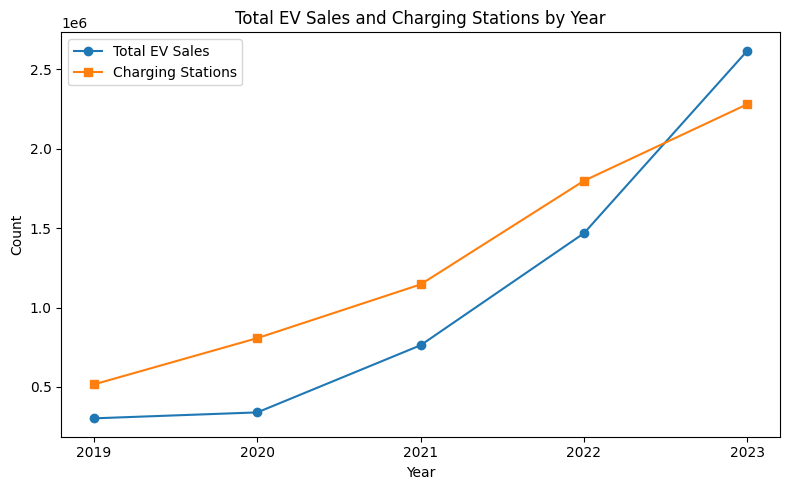

In [44]:
################ Plot sum of total EV sales and charging stations by year to compare trend

# Ensure year columns are integer type before grouping
df['year'] = df['year'].astype(int)
charging_df['year'] = charging_df['year'].astype(int)

# Group by year and sum EV sales and charging stations
ev_sales_sum = (
    df[df['fuel_type'].isin(['BEV', 'PHEV'])]
    .groupby('year')['sales']
    .sum()
)
charging_stock_sum = charging_df.groupby('year')['公共充电桩保有量（台）'].sum()

# Indices are already int, so no need to convert again

# Align years for plotting (intersection)
common_years = sorted(set(ev_sales_sum.index) & set(charging_stock_sum.index))
ev_sales_plot = ev_sales_sum.loc[common_years]
charging_stock_plot = charging_stock_sum.loc[common_years]

# Plot both on the same figure
plt.figure(figsize=(8, 5))
plt.plot(ev_sales_plot.index, ev_sales_plot.values, label='Total EV Sales', marker='o')
plt.plot(charging_stock_plot.index, charging_stock_plot.values, label='Charging Stations', marker='s')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Total EV Sales and Charging Stations by Year')
plt.legend()
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))  # Force integer ticks
plt.tight_layout()
plt.show()


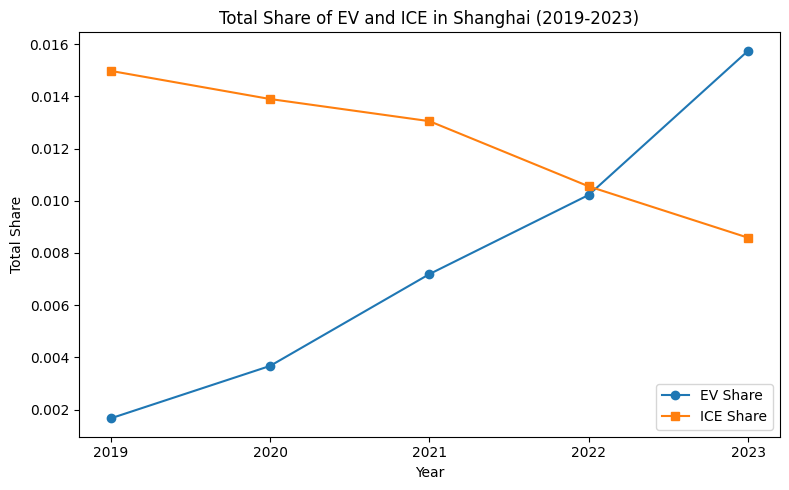

In [45]:
################ Total shares of new sales in Shanghai and trend
years = [f'P01Y{y}' for y in range(2019, 2024)]

ev_shares = []
ice_shares = []
plot_years = []

for market_id in years:
    ev_share = df.loc[(df['is_electric'] == 1) & (df['market_ids'] == market_id), 'shares'].sum()
    ice_share = df.loc[(df['is_electric'] == 0) & (df['market_ids'] == market_id), 'shares'].sum()
    ev_shares.append(ev_share)
    ice_shares.append(ice_share)
    plot_years.append(int(market_id[-4:]))

plt.figure(figsize=(8, 5))
plt.plot(plot_years, ev_shares, marker='o', label='EV Share')
plt.plot(plot_years, ice_shares, marker='s', label='ICE Share')
plt.xlabel('Year')
plt.ylabel('Total Share')
plt.title('Total Share of EV and ICE in Shanghai (2019-2023)')
plt.legend()
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


In [46]:
# Show descriptive statistics of the data set
print(df.describe())

               year          mass         power          sales        prices  \
count  33545.000000  33545.000000  33545.000000   33545.000000  33545.000000   
mean    2021.358235   2116.939542    124.322510     853.967596     19.783194   
std        1.380873    389.310250     43.345584    2500.120569     13.378894   
min     2019.000000    900.000000      0.852018       1.000000      3.380000   
25%     2020.000000   1900.000000     97.164786      19.000000     10.490000   
50%     2021.000000   2070.969241    120.999310     127.000000     16.120000   
75%     2023.000000   2325.000000    148.088235     644.000000     25.080000   
max     2023.000000   3700.000000    814.500000  121388.000000    141.580000   

        market_size        shares  charging_stations_stock  \
count  3.354500e+04  3.354500e+04             33545.000000   
mean   1.831729e+07  4.813643e-05             50044.710896   
std    1.162599e+07  1.131574e-04             68287.338541   
min    1.387538e+06  2.046277e-